In [12]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_gm_wm_volume_ratios_auto(folder_path, output_csv, show_plot=True):
    """
    Automatically detect GM and WM labels in NIfTI masks, compute voxel counts, volumes, and volume ratios.
    Also plots histogram of GM/WM ratios.

    Parameters:
    - folder_path : str : path to folder containing .nii.gz mask files
    - output_csv : str : path to save the CSV file
    - show_plot : bool : whether to display histogram of GM/WM ratios

    Returns:
    - df : pandas DataFrame with results
    """
    results = []

    for filename in os.listdir(folder_path):
        if filename.endswith(".nii") or filename.endswith(".nii.gz"):
            mask_path = os.path.join(folder_path, filename)
            
            # Load mask
            mask_nii = nib.load(mask_path)
            mask_data = mask_nii.get_fdata()
            
            # Unique labels and counts
            labels, counts = np.unique(mask_data, return_counts=True)
            label_counts = dict(zip(labels, counts))
            label_counts.pop(0, None)  # remove background if present
            
            if len(label_counts) < 2:
                print(f"Skipping {filename}: not enough tissue labels")
                continue
            
            # Largest tissue = WM, second largest = GM
            sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
            wm_label, gm_label = sorted_labels[0][0], sorted_labels[1][0]
            
            # Counts
            gm_voxels = label_counts[gm_label]
            wm_voxels = label_counts[wm_label]
            
            # Voxel dimensions -> volume
            voxel_dims = mask_nii.header.get_zooms()
            voxel_volume = np.prod(voxel_dims)
            gm_volume = gm_voxels * voxel_volume
            wm_volume = wm_voxels * voxel_volume
            
            # Ratios
            gm_wm_ratio = gm_volume / wm_volume if wm_volume > 0 else np.inf
            gm_total_ratio = gm_volume / (gm_volume + wm_volume) if (gm_volume + wm_volume) > 0 else np.inf
            
            results.append({
                "filename": filename,
                "gm_label": int(gm_label),
                "wm_label": int(wm_label),
                "gm_voxels": int(gm_voxels),
                "wm_voxels": int(wm_voxels),
                "gm_volume_mm3": float(gm_volume),
                "wm_volume_mm3": float(wm_volume),
                "gm_wm_ratio": float(gm_wm_ratio),
                "gm_gmwm_ratio": float(gm_total_ratio)
            })
    
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")
    
    # Plot histogram
    if show_plot and not df.empty:
        plt.figure(figsize=(8, 5))
        plt.hist(df["gm_wm_ratio"], bins=20, color="skyblue", edgecolor="black")
        plt.title("Histogram of GM/WM Ratios Across Subjects")
        plt.xlabel("GM/WM Volume Ratio")
        plt.ylabel("Number of Subjects")
        plt.grid(axis="y", alpha=0.6)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.hist(df["gm_gmwm_ratio"], bins=20, color="skyblue", edgecolor="black")
        plt.title("Histogram of GM/(GM+WM) Ratios Across Subjects")
        plt.xlabel("GM/(GM+WM) Volume Ratio")
        plt.ylabel("Number of Subjects")
        plt.grid(axis="y", alpha=0.6)
        plt.show()
    
    return df


Results saved to gm_wm_volume_ratios_test.csv


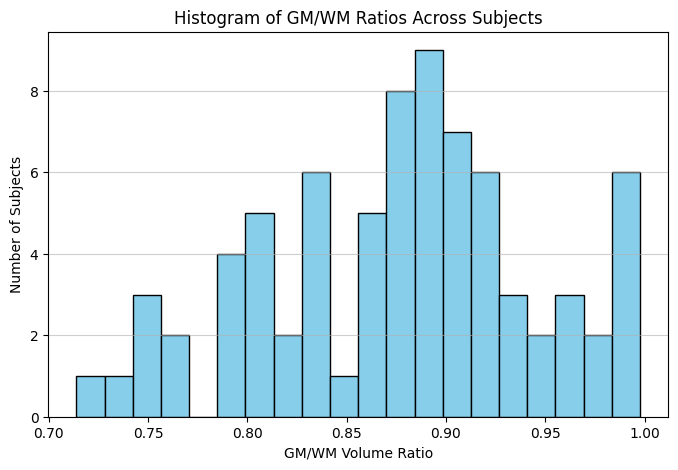

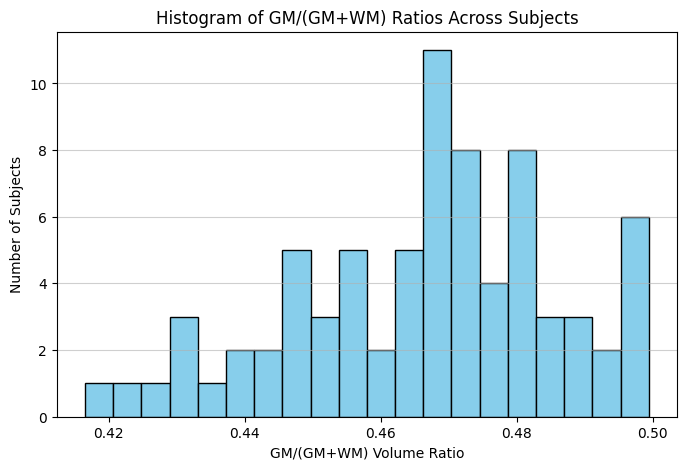

                                            filename  gm_label  wm_label  \
0  ADNI_023_S_1247_MR_MPR-R__GradWarp__B1_Correct...         1         2   
1  ADNI_002_S_0413_MR_MPR-R__GradWarp__B1_Correct...         1         2   
2  ADNI_141_S_0982_MR_MPR-R__GradWarp__B1_Correct...         1         2   
3  ADNI_051_S_1331_MR_MPR-R__GradWarp__B1_Correct...         1         2   
4  ADNI_128_S_0528_MR_MPR-R__GradWarp__B1_Correct...         1         2   

   gm_voxels  wm_voxels  gm_volume_mm3  wm_volume_mm3  gm_wm_ratio  \
0     342108     435637  342108.000000     435637.000     0.785305   
1     532091     538112  438429.473877     443390.625     0.988811   
2     420163     460799  420163.000000     460799.000     0.911814   
3     339602     377171  339602.000000     377171.000     0.900393   
4     354659     383460  354659.000000     383460.000     0.924892   

   gm_gmwm_ratio  
0       0.439872  
1       0.497187  
2       0.476937  
3       0.473793  
4       0.480490  


In [13]:
folder = "../MRIs_SPLIT/test/masks"
df_ratios = compute_gm_wm_volume_ratios_auto(folder, output_csv="gm_wm_volume_ratios_test.csv")
print(df_ratios.head())

Results saved to gm_wm_volume_ratios_val.csv


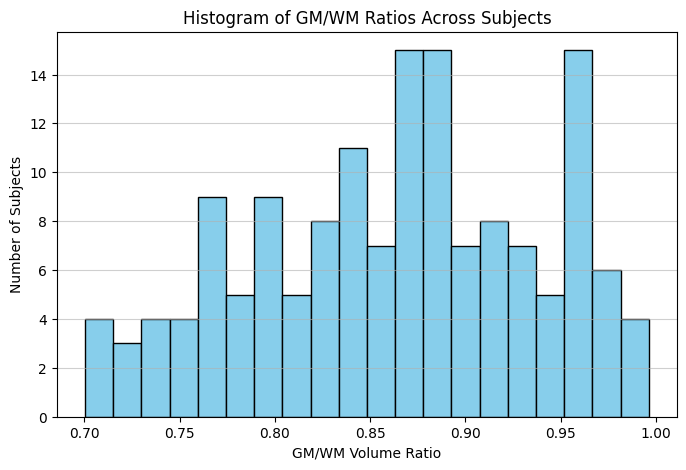

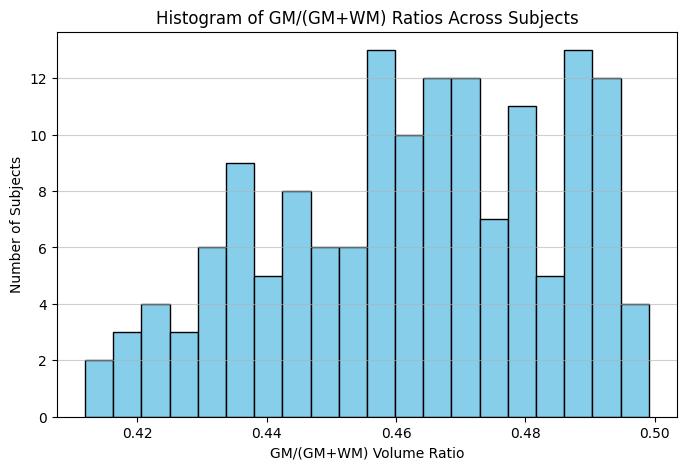

                                            filename  gm_label  wm_label  \
0  ADNI_027_S_0417_MR_MPR-R__GradWarp__B1_Correct...         1         2   
1  ADNI_131_S_0319_MR_MPR-R__GradWarp__B1_Correct...         1         2   
2  ADNI_131_S_1301_MR_MPR-R__GradWarp__B1_Correct...         1         2   
3  ADNI_073_S_0565_MR_MPR-R__GradWarp__B1_Correct...         1         2   
4  ADNI_133_S_0493_MR_MPR-R__GradWarp__B1_Correct...         1         2   

   gm_voxels  wm_voxels  gm_volume_mm3  wm_volume_mm3  gm_wm_ratio  \
0     513003     690871  422701.446533  569260.162354     0.742545   
1     467250     508693  385002.136230  419150.115967     0.918530   
2     463298     602884  381745.788574  496761.108398     0.768470   
3     337443     446951  337443.000000  446951.000000     0.754989   
4     486225     612543  409678.543617  516110.286683     0.793781   

   gm_gmwm_ratio  
0       0.426127  
1       0.478768  
2       0.434539  
3       0.430196  
4       0.442518  


In [14]:
folder = "../MRIs_SPLIT/val/masks"
df_ratios = compute_gm_wm_volume_ratios_auto(folder, output_csv="gm_wm_volume_ratios_val.csv")
print(df_ratios.head())

Results saved to gm_wm_volume_ratios_train.csv


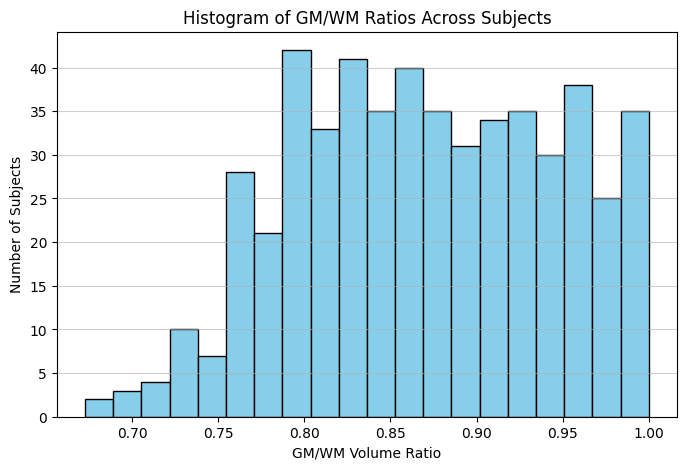

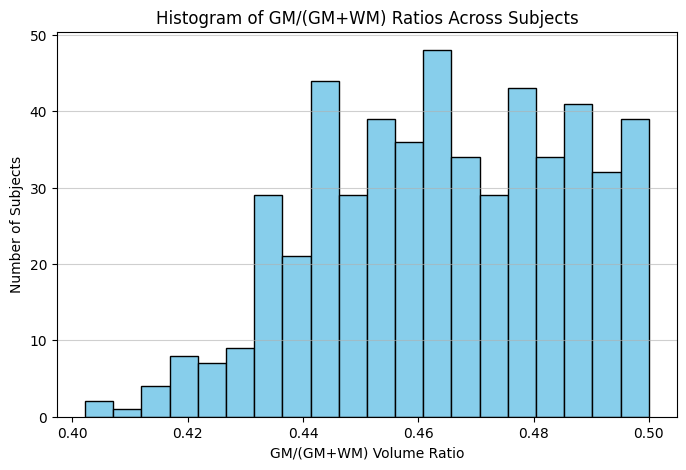

                                            filename  gm_label  wm_label  \
0  ADNI_016_S_1326_MR_MPR-R__GradWarp__B1_Correct...         1         2   
1  ADNI_128_S_0205_MR_MPR-R__GradWarp__B1_Correct...         1         2   
2  ADNI_136_S_0196_MR_MPR-R__GradWarp__B1_Correct...         1         2   
3  ADNI_027_S_0835_MR_MPR-R__GradWarp__B1_Correct...         1         2   
4  ADNI_067_S_0607_MR_MPR-R__GradWarp__B1_Correct...         1         2   

   gm_voxels  wm_voxels  gm_volume_mm3  wm_volume_mm3  gm_wm_ratio  \
0     485928     558229   485928.00000  558229.000000     0.870481   
1     453002     520146   453002.00000  520146.000000     0.870913   
2     455552     457729   375363.28125  377157.073975     0.995244   
3     451302     508144   451302.00000  508144.000000     0.888138   
4     366288     379570   366288.00000  379570.000000     0.965008   

   gm_gmwm_ratio  
0       0.465378  
1       0.465502  
2       0.498808  
3       0.470378  
4       0.491096  


In [15]:
folder = "../MRIs_SPLIT/train/masks"
df_ratios = compute_gm_wm_volume_ratios_auto(folder, output_csv="gm_wm_volume_ratios_train.csv")
print(df_ratios.head())